In [1]:
# 必要なモジュールをインポート
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

# 環境変数の読み込み
load_dotenv("../.env")
os.environ["OPENAI_API_KEY"] = os.environ["API_KEY"]

# モデル名
MODEL_NAME = "gpt-4o-mini"

In [2]:
# 検索ツールの定義
from langchain_community.tools.tavily_search import TavilySearchResults

tool = TavilySearchResults(max_results=2)
tools = [tool]

In [3]:
# 動作確認

tool.invoke("Langgraphのノードとは？")

[{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph/',
  'content': 'Monitoring mechanism: Human-in-the-loop (HITL) ensures humans remain part of the decision-making process. It improves machine learning accuracy by using critical data points instead of relying on random sampling.\n Stateful graphs: Each node represents a step in computation and carries forward information from previous steps. This enables continuous, contextual processing of data throughout the workflow.\n Cyclical graphs: Graphs that contain loops is used for workflows where certain steps may repeat. It becomes important for complex agent run-times.\n Nodes: The individual components or agents within a workflow is called node. They act like “actors” performing tasks or calling tools (e.g., a ToolNode for tool integration).'},
 {'url': 'https://zenn.dev/tomodo_ysys/articles/langgraph-basic-elements',
  'content': '`graph_builder = StateGraph(State)`\n\nちなみに今回のようにstateがmessagesしかない場合はStateGraphでは

In [4]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages


# Stateクラスの定義
class State(TypedDict):
    messages: Annotated[list, add_messages]


# グラフのインスタンスを作成
graph_builder = StateGraph(State)

# 言語モデルの定義
llm = ChatOpenAI(model_name=MODEL_NAME)

# 変更点：ツール定義の紐づけ
llm_with_tools = llm.bind_tools(tools)


# チャットボットノードの作成
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


# グラフにチャットボットノードを追加
graph_builder.add_node("chatbot", chatbot)

In [5]:
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

# ツールノードの作成
tool_node = ToolNode(tools)

# グラフにツールノードを追加
graph_builder.add_node("tools", tool_node)

# 条件付エッジの作成
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,  # ツール呼出と判断したらツールノードを呼ぶ
)

# ツールが呼び出されるたびに、チャットボットに戻って次のステップを決定
# ツールからチャットボットへの戻りエッジを作成
graph_builder.add_edge("tools", "chatbot")

# 開始ノードの指定
graph_builder.set_entry_point("chatbot")

# 記憶を持つ実行可能なステートグラフの作成
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

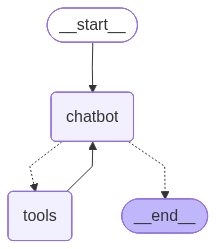

In [6]:
# グラフの可視化
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
# グラフの実行と結果の表示
def stream_graph_updates(user_input: str):
    events = graph.stream(
        {"messages": [("user", user_input)]},
        {"configurable": {"thread_id": "1"}},
        stream_mode="values",
    )
    # 結果をストリーミングで得る
    for event in events:
        print(event["messages"][-1].content, flush=True)


# チャットボットのループ
while True:
    user_input = input("質問:")
    if user_input.strip() == "":
        print("ありがとうございました!")
        break
    stream_graph_updates(user_input)

こんにちは！
こんにちは！どういったことをお手伝いできますか？
1足す2は？
1足す2は3です。何か他にお手伝いできることはありますか？
1メートル以上の魚は？

[{"url": "https://detail.chiebukuro.yahoo.co.jp/qa/question_detail/q13320657663", "content": "Yahoo! JAPAN\n ヘルプ\n\nYahoo!知恵袋\n\nIDでもっと便利に新規取得\n\n登録情報を確認 ログイン\n\nyut\\\\\\\\\\\\\\\\さん\n\n2025/10/3 6:09\n\n8回答\n\n# この魚はなんですか？ 1メートル以上の大きな魚でした。\n\n釣り・288閲覧\n\nパパ王さん\n\n2025/10/4 6:18\n\n### ソウギョかも \n\nこの回答はいかがでしたか？ リアクションしてみよう\n\n## その他の回答（7件）\n\n缶\n\n缶さん\n\n2025/10/3 21:58\n\nソウギョかアオウオかな？(´Д｀)と思います。\n\nrho\\\\\\\\\\\\\\\\\n\nrho\\\\\\\\\\\\\\\\さん\n\n2025/10/3 14:57\n\nライギョだとヒレが背中から尾びれまで繋がっていますが、この写真で見るとヒレは離れている感じなので、ソウギョやレンギョっぽいかな・・・\n物凄く痩せた鯉という可能性も無くはないけど・・・\n\nMajiでAji釣る５秒前\n\nMajiでAji釣る５秒前さん\n\n2025/10/3 10:03\n\nはっきりとは見えませんがシルエット云々でソウギョではないかなと思います\n\nkam\\\\\\\\\\\\\\\\\n\nkam\\\\\\\\\\\\\\\\さん\n\n2025/10/3 7:59\n\nイトウ\n\n1150816989\n\n1150816989さん\n\n2025/10/3 7:45\n\nシルエットから、雷魚に見えます。\n\n12次へ\n\n7件\n\nカウンセラーにお悩み相談\n\n## カテゴリQ&Aランキング\n\n釣り\n\n1\n\n釣れた方に｢何釣れましたか？｣や｢どんな仕掛け使っているんですか？｣などと聞いて情報を集めてみたいのですが、うざっ